<a href="https://colab.research.google.com/github/abi800648-sketch/Dream-Homes/blob/main/K_MEANS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import (KMeans,DBSCAN,AgglomerativeClustering)
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


In [ ]:
# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("marketing_data.csv")


print("First 5 Rows")
print(df.head())


print("\nDataset Shape")
print(df.shape)


First 5 Rows
      ID  Year_Birth   Education Marital_Status   Income   Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced   84835.0        0         0   
1      1        1961  Graduation         Single   57091.0        0         0   
2  10476        1958  Graduation        Married   67267.0        0         1   
3   1386        1967  Graduation       Together   32474.0        1         1   
4   5371        1989  Graduation         Single   21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumStorePurchases  NumWebVisitsMonth  \
0  2014-06-16        0       189  ...                  6                  1   
1  2014-06-15        0       464  ...                  7                  5   
2  2014-05-13        0       134  ...                  5                  2   
3  2014-05-11        0        10  ...                  2                  7   
4  2014-04-08        0         6  ...                  2                  7   

   AcceptedCmp3  AcceptedCmp4  

In [ ]:
# =====================================================
# Data Cleaning
# =====================================================
# Remove spaces in column names
df.columns = df.columns.str.strip()

In [ ]:
# Missing Values

print("\nMissing Values")

print(df.isnull().sum())


Missing Values
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64


In [ ]:
# Fill missing values

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())


for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# =====================================================
# Feature Selection
# =====================================================

# Selecting customer behaviour features

X = df[
[
'Income',
'Recency',
'MntWines',
'MntFruits',
'MntMeatProducts',
'MntFishProducts',
'MntSweetProducts',
'MntGoldProds',
'NumDealsPurchases',
'NumWebPurchases',
'NumCatalogPurchases',
'NumStorePurchases',
'NumWebVisitsMonth'
]
]


print("\nSelected Features")

print(X.head())



Selected Features
    Income  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  84835.0        0       189        104              379              111   
1  57091.0        0       464          5               64                7   
2  67267.0        0       134         11               59               15   
3  32474.0        0        10          0                1                0   
4  21474.0        0         6         16               24               11   

   MntSweetProducts  MntGoldProds  NumDealsPurchases  NumWebPurchases  \
0               189           218                  1                4   
1                 0            37                  1                7   
2                 2            30                  1                3   
3                 0             0                  1                1   
4                 0            34                  2                3   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  
0         

In [ ]:
# =====================================================
# Feature Scaling
# =====================================================


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# =====================================================
# 1. K-MEANS CLUSTERING
# =====================================================


print("\n========== K-MEANS CLUSTERING ==========")


========== K-MEANS CLUSTERING ==========


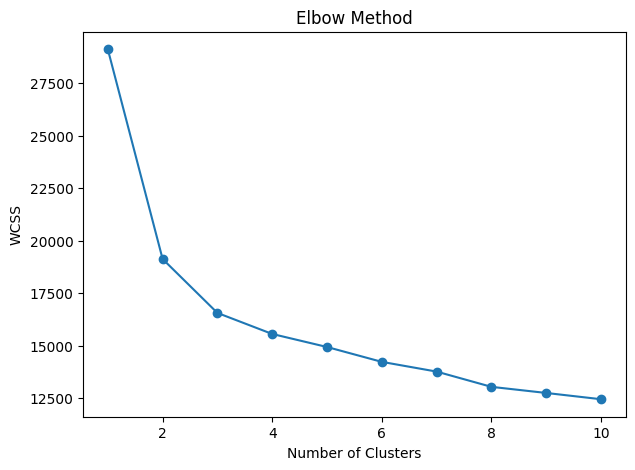

In [ ]:
# Elbow Method

wcss=[]


for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)



plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

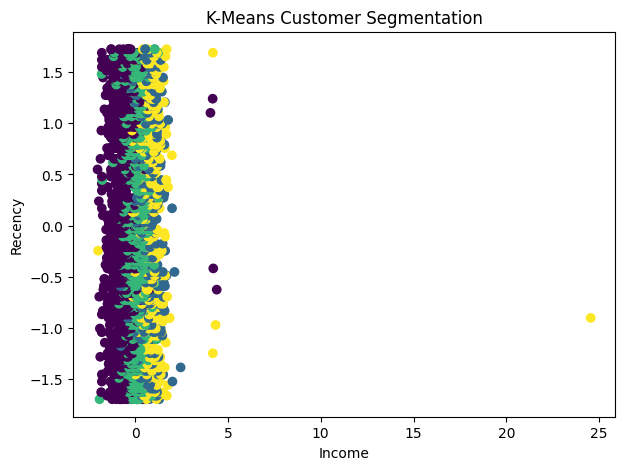

Silhouette Score: 0.26144182420195794


In [ ]:
# KMeans Model

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)


k_labels = kmeans.fit_predict(X_scaled)


df["KMeans_Cluster"] = k_labels



plt.figure(figsize=(7,5))


plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=k_labels,
    cmap="viridis"
)
plt.title("K-Means Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()
print("Silhouette Score:",silhouette_score(X_scaled,k_labels))


========== DBSCAN CLUSTERING ==========
Clusters: 1
Noise Points: 1506


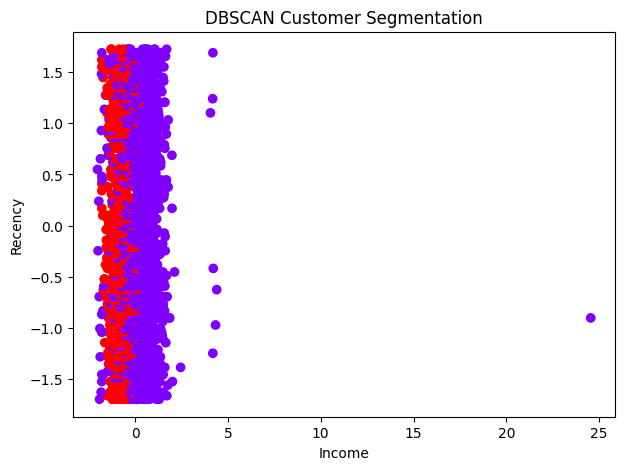

DBSCAN Silhouette Score: 0.18241562205725864


In [ ]:
# =====================================================
# 2. DBSCAN CLUSTERING
# =====================================================


print("\n========== DBSCAN CLUSTERING ==========")
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)
db_labels = dbscan.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = db_labels
print("Clusters:",len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise Points:",sum(db_labels==-1))
plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=db_labels,
    cmap="rainbow"
)

plt.title("DBSCAN Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()
if len(set(db_labels)) > 1:

    print("DBSCAN Silhouette Score:",silhouette_score(X_scaled,db_labels))


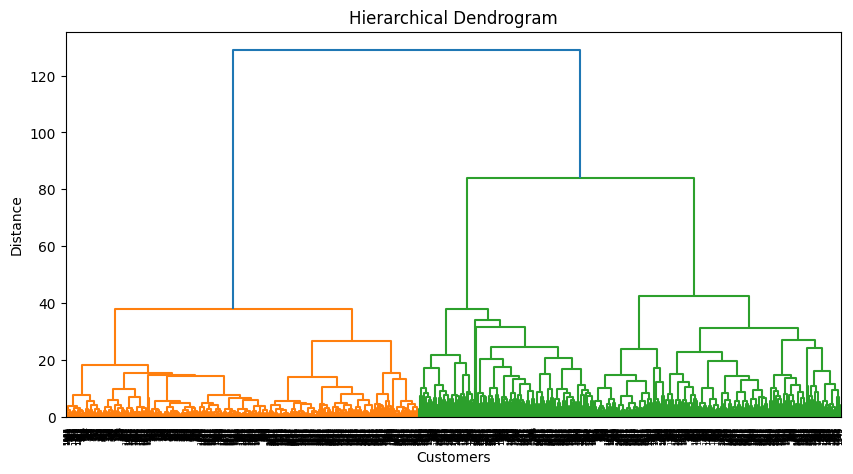

In [ ]:
# Dendrogram
linked = linkage(
    X_scaled,
    method="ward"
)
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

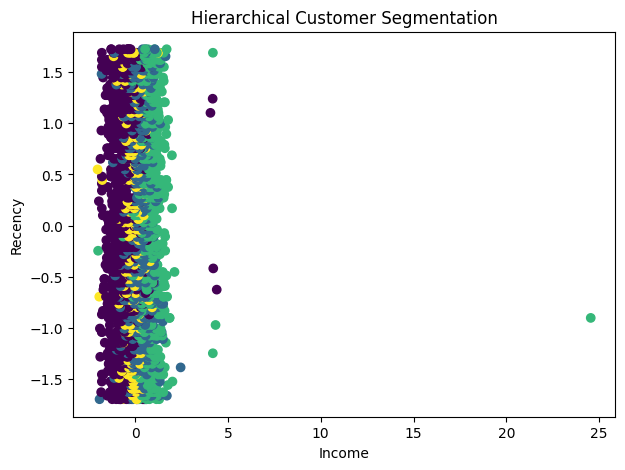

Hierarchical Silhouette Score: 0.22923852519528778


In [ ]:
# Model
hc = AgglomerativeClustering(
    n_clusters=4,
    metric="euclidean",
    linkage="ward"
)
hc_labels = hc.fit_predict(X_scaled)
df["Hierarchical_Cluster"] = hc_labels
plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=hc_labels,
    cmap="viridis"
)
plt.title("Hierarchical Customer Segmentation")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()
print("Hierarchical Silhouette Score:",silhouette_score(X_scaled,hc_labels))

In [ ]:
# =====================================================
# Final Output
# =====================================================
print("\nFinal Dataset")
print(df[["ID","KMeans_Cluster","DBSCAN_Cluster","Hierarchical_Cluster"]].head(20))


Final Dataset
       ID  KMeans_Cluster  DBSCAN_Cluster  Hierarchical_Cluster
0    1826               1              -1                     2
1       1               2              -1                     1
2   10476               0              -1                     0
3    1386               0               0                     0
4    5371               0               0                     0
5    7348               1              -1                     2
6    4073               3              -1                     1
7    1991               0               0                     0
8    4047               2              -1                     1
9    9477               2              -1                     1
10   2079               3              -1                     2
11   5642               0              -1                     0
12  10530               3              -1                     2
13   2964               0               0                     0
14  10311               2

In [ ]:
# Save Result
df.to_csv(
"Marketing_Customer_Clusters.csv",index=False)
print("\nFile Saved Successfully")